# 2MASS + Wise separation

We want to go through and try to separate the two populations using the the 2MASS and Wise filters. These skew much more blue, so we'll need to modify the models and templates that we're using, to see if a GMM can be used to separate the groups. 

For this, we'll be using the Sonora Elf Owl models (T + Y), as well as the SWIRE galaxy templates.

## Stage 1: Setup

We build out our target filters, as well as do all of our imports from the helper modules. 

We also set the REG_COVAR, which will help add some more realism, so that the model doesn't hold on to structure that doesn't normally exist with real data. 

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
from dwarfhunt import planets as helpers
from dwarfhunt import galaxies as galaxy_helpers
from dwarfhunt import plots as ccp
from dwarfhunt.gmm import GMMClassifier, balanced_accuracy, fit_and_score
from species.read.read_model import ReadModel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import dwarfhunt
from dwarfhunt import paths
from dwarfhunt import photometry

randomSeed = 8675309

db = dwarfhunt.init(force_species_init=True)

TARGET_FILTERS = helpers.put_filters_in_wavelength_order((
    "2MASS/2MASS.J", "2MASS/2MASS.H", "2MASS/2MASS.Ks", "WISE/WISE.W1", "WISE/WISE.W2"
))

FILTER_LABELS = [helpers.filter_label(name) for name in TARGET_FILTERS]

COLOR_NAMES = [f"{blue} - {red}" for blue, red in zip(FILTER_LABELS, FILTER_LABELS[1:])]

REG_COVAR = 1e-3

K_CANDIDATES = list(range(2, 21))

def warn_if_k_at_edge(k, candidates, context=""):
    """A selected K sitting on a boundary is a cap, not a choice.

    Silent boundary hits are how a colour-set comparison ends up unfair: sets
    whose optimum lies outside the range get capped while others do not, so they
    are no longer being compared on equal terms.
    """
    if k in (candidates[0], candidates[-1]):
        print(f"  WARNING: K={k} sits at the edge of "
              f"[{candidates[0]}, {candidates[-1]}]{context} -- BIC's optimum is "
              "outside the range, so this value is a cap, not a choice. Widen "
              "K_CANDIDATES or raise REG_COVAR.")
        return True
    return False


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
species

Version: 0.10.4
Working folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/2mass-wise-separation

Configuration file: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/species_config.ini
Database file: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/data/species_database.hdf5
Data folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/data

Configuration settings:
   - Database: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/data/species_database.hdf5
   - Data folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/data
   - Magnitude of Vega: 0.03

Multiprocessing: mpi4py not installed


## Stage 2: Load model data

This stage loads the model data that you'll need. Now, we're using sonora elf owl, which is massive. Try to only run this code once, as it's slow. 

In [4]:
db.add_model('sonora-elfowl-t', wavel_range=(1.0, 5.6), wavel_sampling=3000.0,
             unpack_tar=False)
db.add_model('sonora-elfowl-y', wavel_range=(1.0, 5.6), wavel_sampling=3000.0,
             unpack_tar=False)


-------------------------
Add grid of model spectra
-------------------------

Database tag: sonora-elfowl-t
Model name: Sonora Elf Owl

Please cite Mukherjee et al. (2023) when using Sonora Elf Owl in a publication
Reference URL: https://zenodo.org/records/10385821

Wavelength range (um) = 1.0 - 5.6
Sampling (lambda/d_lambda) = 3000.0
Teff range (K) = 575 - 1200

Adding Sonora Elf Owl model spectra... /Users/mitchellfoote/Documents/Source/research/dwarfhunt/data/sonora-elfowl-t/sonora-elfowl-t_teff_950_logg_5.50_feh_1.0_co_1.145_logkzz_9.0_spec.npy  

Grid points stored in the database:
   - Teff = [ 575.  600.  650.  700.  750.  800.  850.  900.  950. 1000. 1100. 1200.]
   - log(g) = [3.   3.25 3.5  3.75 4.   4.25 4.5  4.75 5.   5.25 5.5 ]
   - [Fe/H] = [-1.  -0.5  0.   0.5  0.7  1. ]
   - C/O = [0.229 0.458 0.687 1.145]
   - log(Kzz) = [2. 4. 7. 8. 9.]

Number of grid points per parameter:
   - teff: 12
   - logg: 11
   - feh: 6
   - c_o_ratio: 4
   - log_kzz: 5


/opt/homebrew/Caskroom/miniconda/base/envs/dwarfhunt/lib/python3.11/site-packages/species/util/data_util.py:413: RuntimeWarning: divide by zero encountered in log10
  flux = np.log10(flux)



Fix missing grid points with a linear interpolation:
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.229, log_kzz = 2.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.229, log_kzz = 4.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.229, log_kzz = 7.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.229, log_kzz = 8.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.229, log_kzz = 9.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.458, log_kzz = 2.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.458, log_kzz = 4.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.458, log_kzz = 7.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.458, log_kzz = 8.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.458, log_kzz = 9.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.687, log_kzz = 2.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.687, log_kzz = 4.0
   - teff = 575.0, logg = 3.0, feh

/opt/homebrew/Caskroom/miniconda/base/envs/dwarfhunt/lib/python3.11/site-packages/species/util/data_util.py:811: UserWarning: Could not interpolate 1428 grid points so storing zeros instead.
  warnings.warn(



The following grid points are missing:
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.229, log_kzz = 2.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.229, log_kzz = 4.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.229, log_kzz = 7.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.229, log_kzz = 8.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.229, log_kzz = 9.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.458, log_kzz = 2.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.458, log_kzz = 4.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.458, log_kzz = 7.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.458, log_kzz = 8.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.458, log_kzz = 9.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.687, log_kzz = 2.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_ratio = 0.687, log_kzz = 4.0
   - teff = 575.0, logg = 3.0, feh = -1.0, c_o_r

## Stage 3: Generating Dwarfs and Galaxies

Now we continue through the process of selecting dwarfs and galaxies for the populations. Now, we also have some missing grid points, especally around the logg=3, so we'll need to make sure to include the deny_list of that axis.  

In [9]:
from dwarfhunt.planets import deny_list
elfowl_t = photometry.planet_magnitudes("sonora-elfowl-t", TARGET_FILTERS, num_samples=400,
                                          radius_range=(0.6, 1.3), distance=10, rng=randomSeed,
                                          deny=helpers.deny_list())
elfowl_y = photometry.planet_magnitudes("sonora-elfowl-y", TARGET_FILTERS, num_samples=400,
                                          radius_range=(0.6, 1.3), distance=10, rng=randomSeed,
                                          deny=helpers.deny_list())

elfowl_planets = helpers.merge_planet_populations({"sonora-elfowl-t": elfowl_t, "sonora-elfowl-y": elfowl_y})
elfowl_planets = helpers.add_color_columns(elfowl_planets, FILTER_LABELS)
names, colors = helpers.color_color_matrix(elfowl_planets, COLOR_NAMES)


GALAXY_TEMPLATE_FILES = (
    "Ell5_template_norm.sed",
    "Sc_template_norm.sed",
    "M82_template_norm.sed",
    "Sey2_template_norm.sed",
    "QSO1_template_norm.sed"
)

GALAXY_TYPE = {"Ell5_template_norm.sed": "quiescent", "Sc_template_norm.sed": "spiral",
                 "M82_template_norm.sed": "starburst", "Sey2_template_norm.sed": "AGN",
                 "QSO1_template_norm.sed": "AGN"}

GALAXY_REDSHIFTS = np.linspace(0.0, 5.0, 90)

all_galaxy_data = []
for sed in GALAXY_TEMPLATE_FILES:
    data = dict(photometry.galaxy_magnitudes_swire(
          paths.galaxy_template(f"swire-library/{sed}"), TARGET_FILTERS,
          redshifts=GALAXY_REDSHIFTS))
    data.update(helpers.color_pairs({l: data[f"mag_{l}"] for l in FILTER_LABELS}, order=FILTER_LABELS))
    all_galaxy_data.append(data)

all_g_redshift = np.concatenate([data["redshift"] for data in all_galaxy_data])
all_type = np.concatenate([np.full(len(data["redshift"]), GALAXY_TYPE[sed], dtype=object) for sed, data in zip(GALAXY_TEMPLATE_FILES, all_galaxy_data)])

total_colors_len = len(names)

all_dwarf_color_data = []
all_galaxy_color_data = []

for i in range(total_colors_len):
    dwarf_color = colors[:, i]
    galaxy_color = np.concatenate([data[COLOR_NAMES[i]] for data in all_galaxy_data])
    all_dwarf_color_data.append(dwarf_color)
    all_galaxy_color_data.append(galaxy_color)

color_data_pairs = []

for i in range(len(all_dwarf_color_data)):
    all_certain_color = np.concatenate((all_dwarf_color_data[i], all_galaxy_color_data[i]))
    color_data_pairs.append(all_certain_color)

X = np.column_stack(color_data_pairs)
Y = np.concatenate((np.zeros(len(all_dwarf_color_data[0])), np.ones(len(all_galaxy_color_data[0]))))

DWARF_CLASS, GALAXY_CLASS = 0.0, 1.0
CLASS_LABELS = {DWARF_CLASS: "brown_dwarf", GALAXY_CLASS: "galaxy"}

n_planets = len(all_dwarf_color_data[0])

all_galaxy_redshift = np.concatenate([data["redshift"] for data in all_galaxy_data])
all_galaxy_type = np.concatenate([np.full(len(data["redshift"]), GALAXY_TYPE[sed], dtype=object) for sed, data in zip(GALAXY_TEMPLATE_FILES, all_galaxy_data)])

assert len(GALAXY_TYPE) == len(all_galaxy_data), (
    f"{len(GALAXY_TYPE)} AGN fractions for {len(all_galaxy_data)} "
    "templates -- zip would drop the extras")
assert len(all_galaxy_type) == len(all_g_redshift)

print(f"colors used ({len(names)}): {names}")
print(f"X: {X.shape}   planets: {int((Y == 0).sum())}   galaxies: {int((Y == 1).sum())}")
print(f"rank(X): {np.linalg.matrix_rank(X)} of {X.shape[1]} columns")

idx = np.arange(len(X))
X_train, X_test, Y_train, Y_test, idx_train, idx_test = train_test_split(
    X, Y, idx, stratify=Y, random_state=0)

sonora-elfowl-t: dropping logg = [np.float64(3.0)] (no spectra)
computing planet magnitudes for 5 filter(s): J, H, Ks, W1, W2
sonora-elfowl-y: dropping logg = [np.float64(3.0)] (no spectra)
computing planet magnitudes for 5 filter(s): J, H, Ks, W1, W2
galaxy magnitudes: cache hit (galaxy_Ell5_template_norm_651fa41ed8cec037.npz)
galaxy magnitudes: cache hit (galaxy_Sc_template_norm_a0d1341010468af1.npz)
galaxy magnitudes: cache hit (galaxy_M82_template_norm_88257c408275582c.npz)
galaxy magnitudes: cache hit (galaxy_Sey2_template_norm_661969be1c44e0f9.npz)
galaxy magnitudes: cache hit (galaxy_QSO1_template_norm_6edb8306087693b0.npz)
colors used (4): ['J - H', 'H - Ks', 'Ks - W1', 'W1 - W2']
X: (1250, 4)   planets: 800   galaxies: 450
rank(X): 4 of 4 columns


## Stage 4: Compute BIC on single run

Now that we have our data needed for computation, let's determine a BIC. 

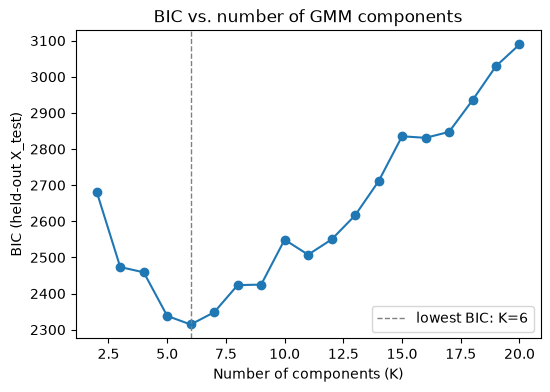

K= 2  BIC=2681.3377
K= 3  BIC=2473.3672
K= 4  BIC=2458.8176
K= 5  BIC=2338.1400
K= 6  BIC=2314.3987  <-- lowest BIC
K= 7  BIC=2348.2640
K= 8  BIC=2423.4301
K= 9  BIC=2424.7426
K=10  BIC=2549.1661
K=11  BIC=2507.5872
K=12  BIC=2549.7181
K=13  BIC=2616.4057
K=14  BIC=2710.7900
K=15  BIC=2835.3274
K=16  BIC=2831.0261
K=17  BIC=2847.4332
K=18  BIC=2935.1167
K=19  BIC=3029.5264
K=20  BIC=3089.3635


In [10]:
K_candidates = K_CANDIDATES
bic_scores = []
for k in K_candidates:
    candidate = GMMClassifier(n_components=k, random_state=0,
                              reg_covar=REG_COVAR).fit(X_train, Y_train)
    bic_scores.append(candidate.bic(X_test))

best_k = K_candidates[int(np.argmin(bic_scores))]
warn_if_k_at_edge(best_k, K_candidates, " in the BIC sweep")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(K_candidates), bic_scores, marker="o")
ax.axvline(best_k, color="0.5", linestyle="--", linewidth=1,
           label=f"lowest BIC: K={best_k}")
ax.set_xlabel("Number of components (K)")
ax.set_ylabel("BIC (held-out X_test)")
ax.set_title("BIC vs. number of GMM components")
ax.legend()
plt.show()

for k, bic_val in zip(K_candidates, bic_scores):
    flag = "  <-- lowest BIC" if k == best_k else ""
    print(f"K={k:2d}  BIC={bic_val:9.4f}{flag}")

## Stage 5: Make a GMM

Now that we have a usable K, let's do a single run, and see what the confusion matrix looks like. 

BIC: 2314.3987
Balanced accuracy score: 0.9275


,component,assigned_class,weight,margin,degenerate,mass_class_0.0,n_class_0.0,mass_class_1.0,n_class_1.0
1,1,0.0,0.103599,0.164132,False,0.164132,108,1.079116e-44,0
3,3,0.0,0.130513,0.204751,False,0.204751,119,1.266604e-63,0
4,4,0.0,0.146828,0.228059,False,0.228061,125,2.486361e-06,0
5,5,0.0,0.180157,0.279484,False,0.279485,178,1.350938e-06,0
2,2,1.0,0.228992,0.295760,False,0.122494,70,4.182539e-01,142
0,0,1.0,0.209911,0.580665,False,0.001077,0,5.817422e-01,195


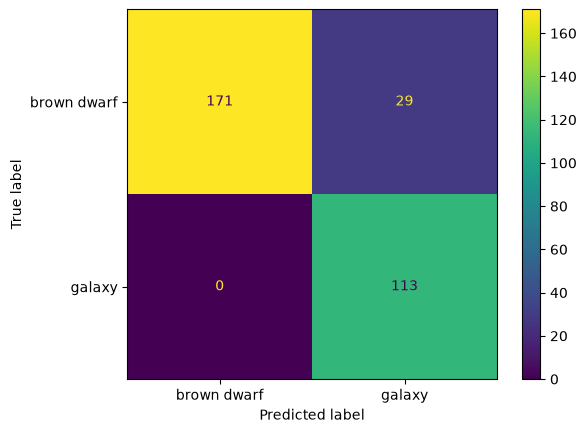

In [12]:
K = best_k

clf = GMMClassifier(n_components=K, random_state=0,
                    reg_covar=REG_COVAR).fit(X_train, Y_train)
pred_best = clf.predict(X_test)
score = clf.score(X_test, Y_test)

matrix = ConfusionMatrixDisplay.from_predictions(
    Y_test, pred_best, display_labels=["brown dwarf", "galaxy"]
)

bic = clf.bic(X_test)
print(f"BIC: {bic:.4f}")
print(f"Balanced accuracy score: {score:.4f}")

import pandas as pd

table = pd.DataFrame(clf.component_table(X_train, Y_train)).sort_values("margin")
table

# Stage 6: Show the Color-Color Plots

Now that we have the data, let's plot it color/color and see what it looks like. 

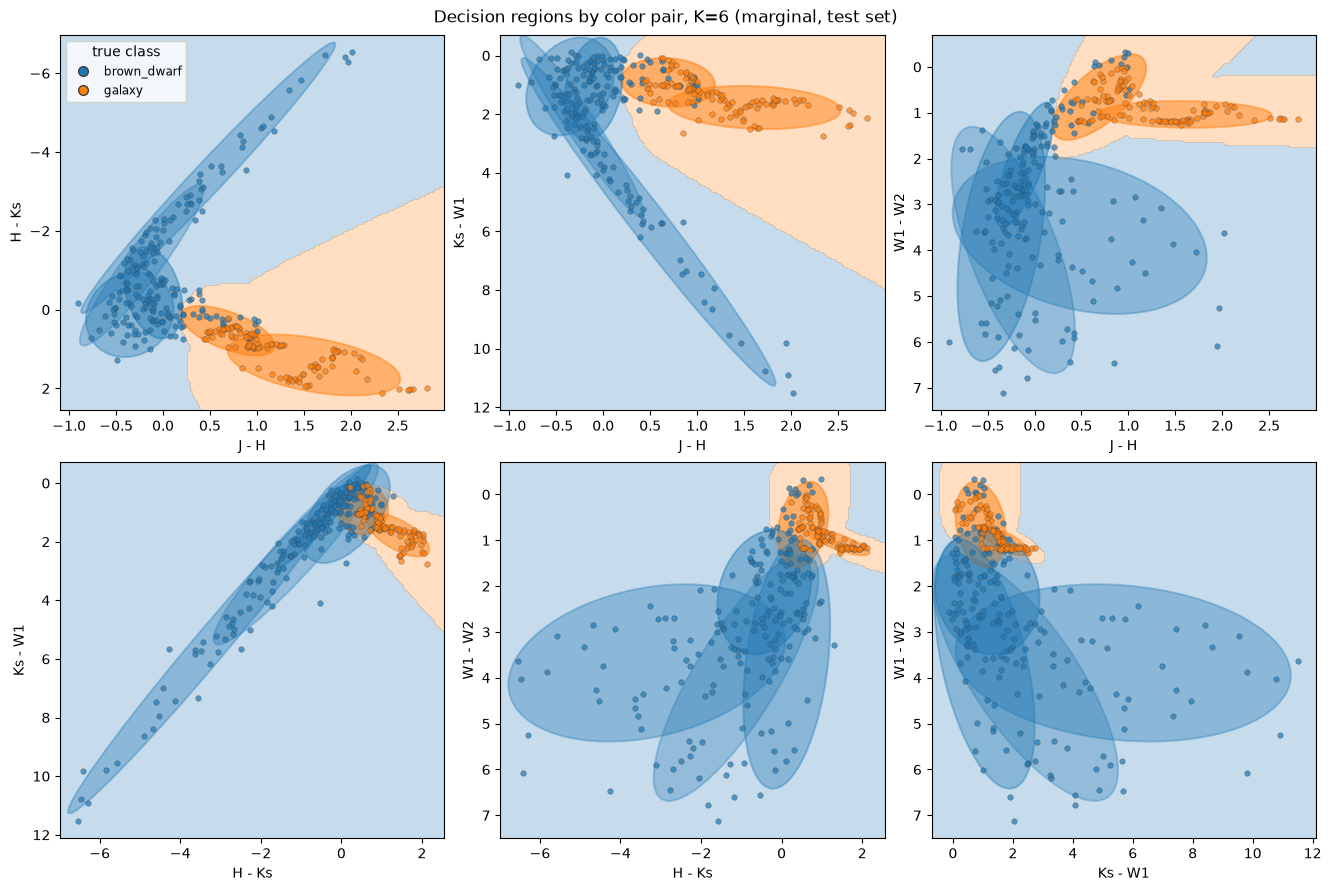

In [13]:
class_colors = ccp.class_color_map(clf.classes_)

fig, axes, pairs = ccp.plot_decision_grid(
    clf, X_test, Y_test, names,
    mode="marginal",
    class_colors=class_colors,
    class_labels=CLASS_LABELS,
    suptitle=f"Decision regions by color pair, K={K} (marginal, test set)")
plt.show()